In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import os

In [2]:
df=pd.read_csv("pre_final_database.csv")
df.shape

(5529, 37)

In [3]:
df.drop(columns=[#'sub_user',  ##As it has irrelevant data and very weak correlation with other table
                 'live_interview_credit', ##As it har irrelevant data and very weak correlation with other table
                 'pre_recorded_credit',
                 'ai_live_interview_credit',#As it has strong correlation 1
                 'referral_credit'], #has 200,400,600,44000==1 or 2, almost all are 0 and has strong correlation with ai_kit_count of 1
        inplace=True)
df.shape

(5529, 33)

In [ ]:
df['company_size'] = pd.Categorical(df['company_size'], categories=['1-25', '26-100', '101-500', '500-1000', 'More than 1000'], ordered=True).codes
df = pd.get_dummies(df, columns=['jobma_catcher_otype', 'per_sub_user'], prefix=['otype', 'subuser'], drop_first=True)

df = df.astype({col: int for col in df.columns if df[col].dtype == 'bool'})
df['sub_user'] = df['sub_user'].apply(lambda x: 1000 if x > 1000 else x)      #To handele outlier

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

In [ ]:
# Load and preprocess data
X = df.values
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test sets and converting to tensor
X_train_scaled, X_test_scaled = train_test_split(X_scaled, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor)
test_dataset = TensorDataset(X_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [ ]:
# Autoencoder
class AutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=500, latent_dim=10):
        super(AutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_bar = self.decoder(z)
        return x_bar, z


# Pretrain Autoencoder
input_dim = X_train_scaled.shape[1]
autoencoder = AutoEncoder(input_dim).to(device)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
criterion = nn.SmoothL1Loss()

print("Pretraining Autoencoder...")
for epoch in range(50):
    autoencoder.train()
    total_loss = 0
    for batch in train_loader:
        x_batch = batch[0].to(device)
        x_bar, _ = autoencoder(x_batch)
        loss = criterion(x_bar, x_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[Pretrain] Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

# Evaluate reconstruction on test data
autoencoder.eval()
recon_loss_test = 0
with torch.no_grad():
    for batch in test_loader:
        x_batch = batch[0].to(device)
        x_bar, _ = autoencoder(x_batch)
        loss = criterion(x_bar, x_batch)
        recon_loss_test += loss.item()
print(f"Test Reconstruction Loss: {recon_loss_test/len(test_loader):.4f}")

# Extract Latent Features for clustering
autoencoder.eval()
with torch.no_grad():
    _, latent_train = autoencoder(X_train_tensor.to(device))
    _, latent_all = autoencoder(torch.tensor(X_scaled, dtype=torch.float32).to(device))

latent_train_np = latent_train.cpu().numpy()
latent_all_np = latent_all.cpu().numpy()

# Determine Optimal Cluster Count using silhouette score
scores = []
K_range = range(2, 20)
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10)
    labels = kmeans.fit_predict(latent_train_np)
    score = silhouette_score(latent_train_np, labels)
    scores.append(score)
    print(f"Clusters: {k}, Silhouette Score: {score:.4f}")

# Initialize KMeans
kmeans = KMeans(n_clusters=13, n_init=20)
cluster_ids = kmeans.fit_predict(latent_train_np)
cluster_centers = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32).to(device)

# Define Deep Embedding Clustering (DEC) model
class DEC(nn.Module):
    def __init__(self, encoder, cluster_centers):
        super(DEC, self).__init__()
        self.encoder = encoder
        self.cluster_centers = nn.Parameter(cluster_centers)

    def forward(self, x):
        z = self.encoder(x)
        q = 1.0 / (1.0 + torch.sum((z.unsqueeze(1) - self.cluster_centers) ** 2, dim=2))
        q = q.pow((1 + 1) / 2.0)
        q = (q.t() / torch.sum(q, dim=1)).t()
        return q, z

def target_distribution(q):
    weight = q**2 / q.sum(0)
    return (weight.t() / weight.sum(1)).t()


# Train DEC
dec = DEC(autoencoder.encoder, cluster_centers.clone()).to(device)
optimizer = torch.optim.Adam(dec.parameters(), lr=1e-3)

print("Training DEC...")
for epoch in range(100):
    dec.train()
    total_loss = 0
    all_q = []

    for batch in train_loader:
        x = batch[0].to(device)
        q, _ = dec(x)
        all_q.append(q.detach().cpu())

    q_all = torch.cat(all_q, dim=0)
    p_all = target_distribution(q_all)

    entropy = -torch.sum(q_all * torch.log(q_all + 1e-10)) / q_all.size(0)

    idx = 0
    for batch in train_loader:
        x = batch[0].to(device)
        q, z = dec(x)
        p = p_all[idx:idx + len(x)].to(device)
        kl_loss = F.kl_div(q.log(), p, reduction='batchmean')
        x_bar = autoencoder.decoder(z)
        recon_loss = F.smooth_l1_loss(x_bar, x)
        loss = kl_loss + 0.1 * recon_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        idx += len(x)
        total_loss += loss.item()

    print(f"[DEC] Epoch {epoch+1}, KL Loss: {total_loss/len(train_loader):.4f}, Entropy: {entropy:.4f}")

In [25]:
# Final predictions on full dataset
dec.eval()
with torch.no_grad():
    q, _ = dec(torch.tensor(X_scaled, dtype=torch.float32).to(device))
    preds = torch.argmax(q, dim=1).cpu().numpy()

df['dec_cluster'] = preds
print("Clustering complete. 'dec_cluster' column added to DataFrame.")

Clustering complete. 'dec_cluster' column added to DataFrame.


In [26]:
df['dec_cluster'].tail(10)

5519    5
5520    0
5521    0
5522    0
5523    5
5524    0
5525    0
5526    5
5527    0
5528    0
Name: dec_cluster, dtype: int64

C:\Program Files\Python310\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


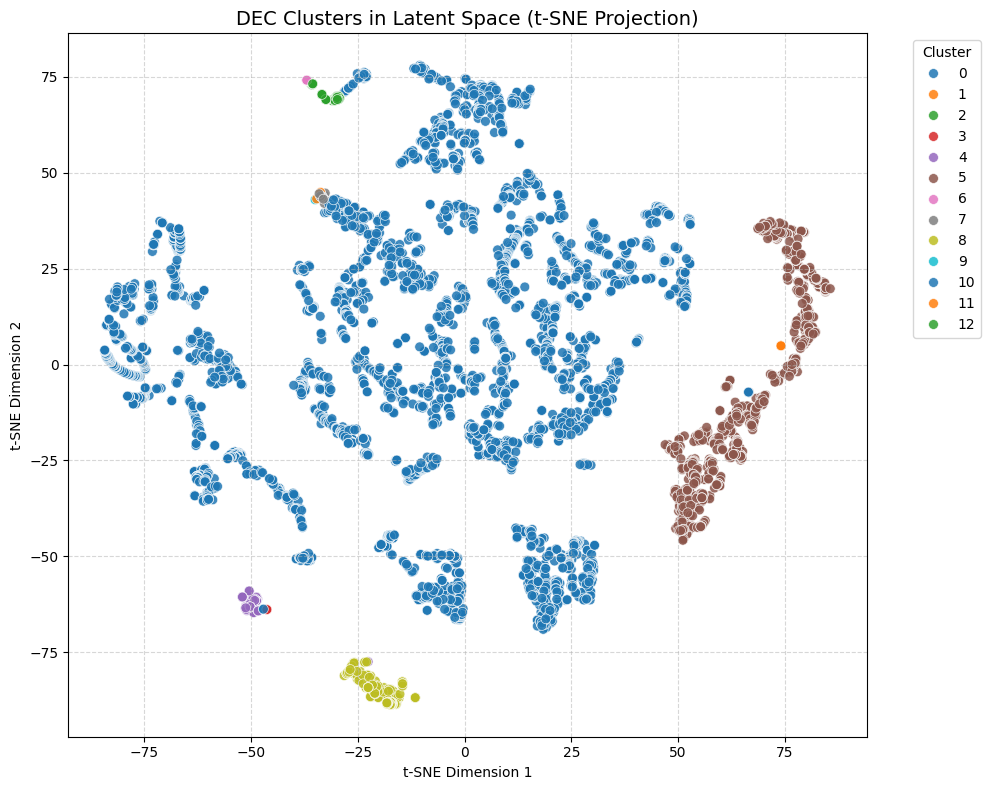

In [34]:
# 1. Drop the cluster column if already added
if 'dec_cluster' in df.columns:
    df = df.drop(columns=['dec_cluster'])

# 2. Reprocess the input
X = df.values
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

# 3. Forward pass through models
autoencoder.eval()
dec.eval()

with torch.no_grad():
    _, latent = autoencoder(X_tensor.to(device))
    q, _ = dec(X_tensor.to(device))
    preds = torch.argmax(q, dim=1).cpu().numpy()
    latent_np = latent.cpu().numpy()

# 4. t-SNE projection
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)
latent_2d = tsne.fit_transform(latent_np)

# 5. Plot
tsne_df = pd.DataFrame({
    'Dim1': latent_2d[:, 0],
    'Dim2': latent_2d[:, 1],
    'Cluster': preds
})

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=tsne_df,
    x='Dim1', y='Dim2',
    hue='Cluster',
    palette='tab10',
    s=50,
    alpha=0.85,
    edgecolor='white',
    linewidth=0.5
)

plt.title("DEC Clusters in Latent Space (t-SNE Projection)", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [35]:
sil_score = silhouette_score(latent_np, preds)
print(f"Silhouette Score: {sil_score}")

Silhouette Score: 0.841090202331543
